<a href="https://colab.research.google.com/github/tim-parisi/data-science-project/blob/main/Data_Science_Project_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Project

Team Members:
Ignacio, Timothy, Jamie, Megan

...




In [3]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

### Gathering Datasets

In [4]:
first_student = pd.read_csv('datasets/first_student.csv')
second_student = pd.read_csv('datasets/second_student.csv')
third_student = pd.read_csv('datasets/third_student.csv')
first_dummy = pd.read_csv('datasets/first_dummy.csv')
second_dummy = pd.read_csv('datasets/second_dummy.csv')
third_dummy = pd.read_csv('datasets/third_dummy.csv')

#### PCA

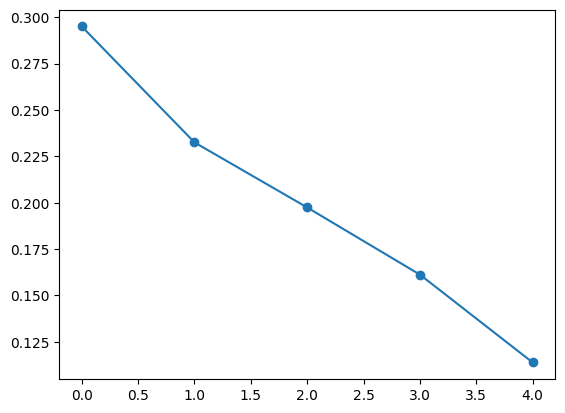

Total variance with 4 components: 0.8861%


In [5]:
scaler = StandardScaler()
pca = PCA(n_components=5)
X_scaled = scaler.fit_transform(first_dummy.drop(columns=['dropout']))
X_pca = pca.fit_transform(X_scaled)
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.show()
total_components = 4
pca_1 = PCA(n_components=total_components)
X_pca_1 = pca_1.fit_transform(X_scaled)
print(f'Total variance with {total_components} components: {pca_1.explained_variance_ratio_.sum():.4f}%')

#### PCA

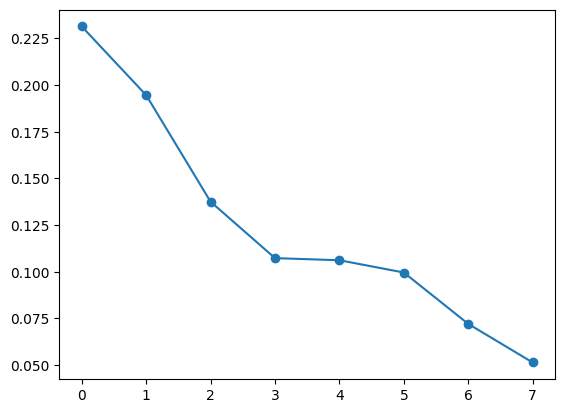

Total variance with 6 components: 0.8765%


In [6]:
scaler = StandardScaler()
pca = PCA(n_components=8)
X_scaled = scaler.fit_transform(second_dummy.drop(columns=['dropout']))
X_pca = pca.fit_transform(X_scaled)
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.show()
total_components = 6
pca_2 = PCA(n_components=total_components)
X_pca_2 = pca_2.fit_transform(X_scaled)
print(f'Total variance with {total_components} components: {pca_2.explained_variance_ratio_.sum():.4f}%')

#### PCA

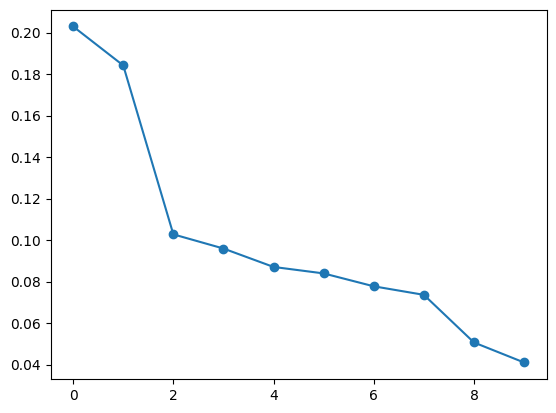

Total variance with 7 components: 0.8347%


In [7]:
scaler = StandardScaler()
pca = PCA(n_components=10)
X_scaled = scaler.fit_transform(third_dummy.drop(columns=['dropout']))
X_pca = pca.fit_transform(X_scaled)
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.show()
total_components = 7
pca_3 = PCA(n_components=total_components)
X_pca_3 = pca_3.fit_transform(X_scaled)
print(f'Total variance with {total_components} components: {pca_3.explained_variance_ratio_.sum():.4f}%')

# Unit Tests

# Modeling

### Visualizing Datasets

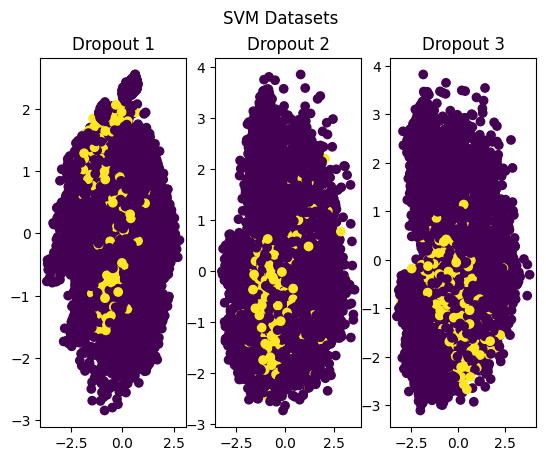

In [8]:
datasets = {1: (X_pca_1, first_dummy['dropout']), 2: (X_pca_2, second_dummy['dropout']), 3: (X_pca_3, third_dummy['dropout'])}
graphing_datasets = X_pca_1[:,0], X_pca_2[:1]
fig, axes = plt.subplots(1, 3)
fig.suptitle('SVM Datasets')
for ix, (X, y) in enumerate(datasets.values(), start=0):
    axes[ix].scatter(X[:,0], X[:,1], c=y)
    axes[ix].set_title(f'Dropout {ix+1}')
plt.show()

##Model 3: Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc


Random Forest on Dataset 1
Accuracy: 0.9436
Precision: 0.6863
Recall (Sensitivity): 0.5707
F1-Score: 0.6231


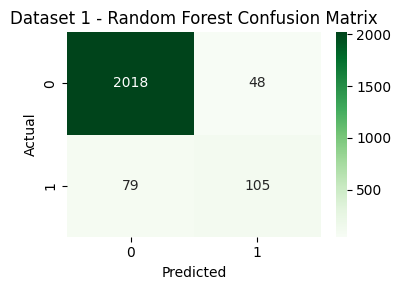

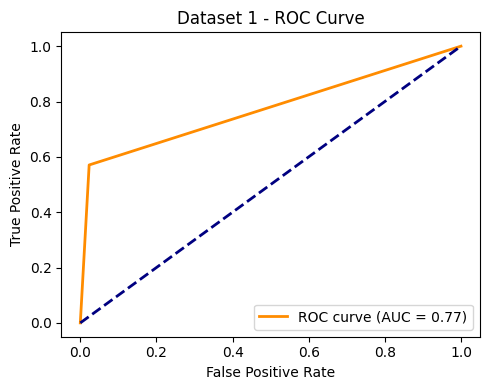


Random Forest on Dataset 2
Accuracy: 0.9297
Precision: 0.7957
Recall (Sensitivity): 0.5804
F1-Score: 0.6712


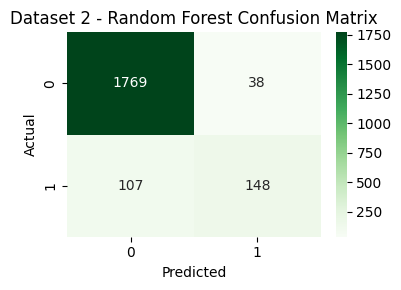

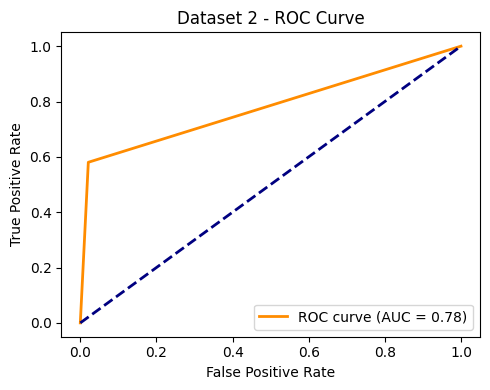


Random Forest on Dataset 3
Accuracy: 0.9123
Precision: 0.6870
Recall (Sensitivity): 0.3911
F1-Score: 0.4984


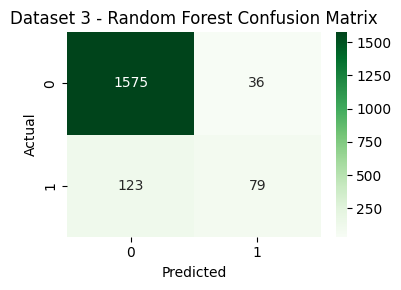

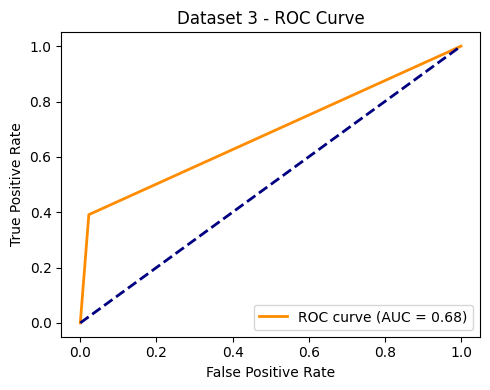

In [10]:
for ix, (X, y) in enumerate(datasets.values(), start=1):
    print(f"\nRandom Forest on Dataset {ix}")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Random Forest model with balanced class weights
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(X_train, y_train)

    # Predictions
    y_pred = rf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall (Sensitivity): {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"Dataset {ix} - Random Forest Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Dataset {ix} - ROC Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
